# 🌟 Exercise 1 : Visualizing the Distribution of CGPA

### Objective
Create a histogram to visualize the distribution of students’ CGPA.

**Dataset Overview**: The CGPA of students is categorized into different ranges. This exercise will help us understand the overall academic performance distribution among the students.

**Tasks**:
- Import necessary libraries.
- Load the dataset into a pandas DataFrame. (For the purpose of this exercise, let’s assume the DataFrame is already loaded and named df).
- Use Seaborn’s histplot to create a histogram of the CGPA categories.
- Customize the histogram with an appropriate color and add a title.
- Display the plot.


### Answer

In [375]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ========= BASIC WORKFLOW ============
df = pd.read_csv('data/Student Mental health.csv')

df.head()

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [376]:
df.shape

(101, 11)

In [377]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    str    
 1   Choose your gender                            101 non-null    str    
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    str    
 4   Your current year of Study                    101 non-null    str    
 5   What is your CGPA?                            101 non-null    str    
 6   Marital status                                101 non-null    str    
 7   Do you have Depression?                       101 non-null    str    
 8   Do you have Anxiety?                          101 non-null    str    
 9   Do you have Panic attack?                     101 non-null    str    
 10  D

In [378]:
# ============ DATA PREPROCESSING ================
# Drop the Timestamp column (since it is not relevant for this analysis)
df = df.drop(columns=['Timestamp'])

# Encode all columns with values 'Yes'/'No' to 1/0
binary_mapping = {'Yes': 1, 'No': 0}
# The columns we want encoded
columns = ['Marital status', 
   'Do you have Depression?', 
   'Do you have Anxiety?', 
   'Do you have Panic attack?', 'Did you seek any specialist for a treatment?']

# Encoding using replace method
df[columns] = df[columns].replace(binary_mapping)

# Check if encoding took place
df.head()

,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,Female,18.0,Engineering,year 1,3.00 - 3.49,0,1,0,1,0
1,Male,21.0,Islamic education,year 2,3.00 - 3.49,0,0,1,0,0
2,Male,19.0,BIT,Year 1,3.00 - 3.49,0,1,1,1,0
3,Female,22.0,Laws,year 3,3.00 - 3.49,1,1,0,0,0
4,Male,23.0,Mathemathics,year 4,3.00 - 3.49,0,0,0,0,0


In [379]:
# Check which CGPA groups there are
cgpa_values = df['What is your CGPA?'].values.unique().tolist()
print(cgpa_values)

# Clean the strings first
df['What is your CGPA?'] = df['What is your CGPA?'].str.strip()

# Create custom order for cgpa
cgpa_asc_order = ['0 - 1.99', '2.00 - 2.49', '2.50 - 2.99', '3.00 - 3.49', '3.50 - 4.00']

# Convert column to a Categorical type and specify the exact order. 
# Seaborn will automatically respect this sequence.
df['What is your CGPA?'] = pd.Categorical(df['What is your CGPA?'], categories=cgpa_asc_order, ordered=True)

['3.00 - 3.49', '3.50 - 4.00', '3.50 - 4.00 ', '2.50 - 2.99', '2.00 - 2.49', '0 - 1.99']


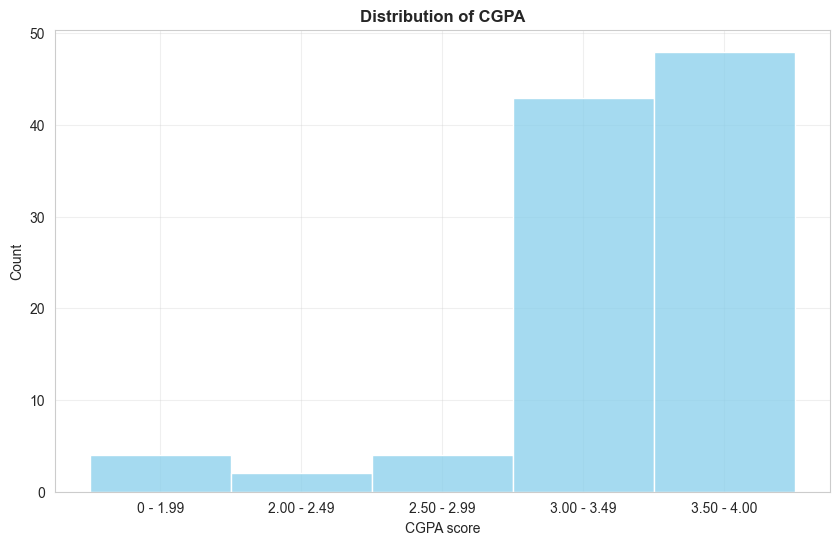

In [380]:
fig, axs = plt.subplots(figsize=(10,6))

# Create histogram of CGPA groups
axs = sns.histplot(data=df, x='What is your CGPA?', color='skyblue')
axs.set_title('Distribution of CGPA', fontweight='bold')
axs.set_xlabel('CGPA score')
axs.grid(True, alpha=0.3)
plt.show()

**Observation**: By visual inspection of the histogram, we can see that the majority of the students have CGPA scores between 3.00 and 4.00.

# 🌟 Exercise 2: Comparing Anxiety Levels Across Different Genders

### Objective:

Use a bar plot to compare the proportion of students experiencing anxiety across different genders.

**Dataset Overview**: The dataset includes a ‘Do you have Anxiety?’ column with responses and a ‘Choose your gender’ column.

**Tasks**:

- Import necessary libraries.
- Assuming the dataset is loaded into df, create a bar plot using Seaborn to compare anxiety - levels across genders.
- Customize your plot with an appropriate color palette.
- Add a title to your plot.
- Display the plot.

### Answer

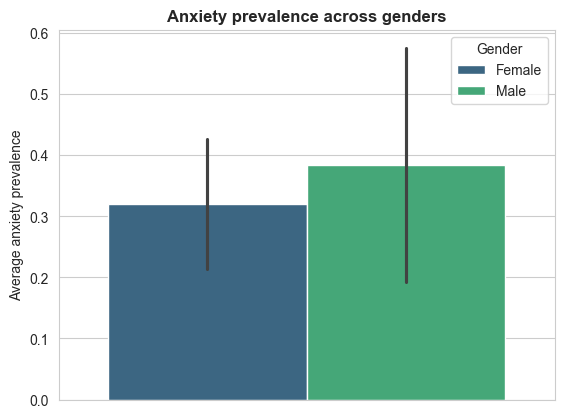

In [381]:
# Create barplot
axs2 = sns.barplot(data=df, hue='Choose your gender', y='Do you have Anxiety?', palette='viridis')
axs2.legend(title='Gender')
axs2.set_ylabel('Average anxiety prevalence') 
axs2.set_title('Anxiety prevalence across genders', fontweight='bold')
plt.show()

**Observation**: In principle, it looks like male students have a higher prevalence of anxiety disorders, but given the wide range of uncertainty shown by the error bar, it is not possible to conclusively state that the prevalence is truly higher among male students. In fact, maybe it is the opposite, since the error bars overlap.

# 🌟 Exercise 3: Exploring the Relationship Between Age and Panic Attacks

### Objective:
Create a scatter plot to explore if there’s any visible relationship between students’ age and the occurrence of panic attacks.

**Dataset Overview**: The dataset records students’ ages and their responses to whether they have experienced panic attacks.

**Tasks**:

- Import necessary libraries.
- Use Seaborn’s scatterplot to create a scatter plot with age on the x-axis and the occurrence of panic attacks on the y-axis. For simplicity, convert panic attack responses to numeric (e.g., Yes=1, No=0).
- Customize the scatter plot to improve readability.
- Add a title.
- Display the plot.

### Answer

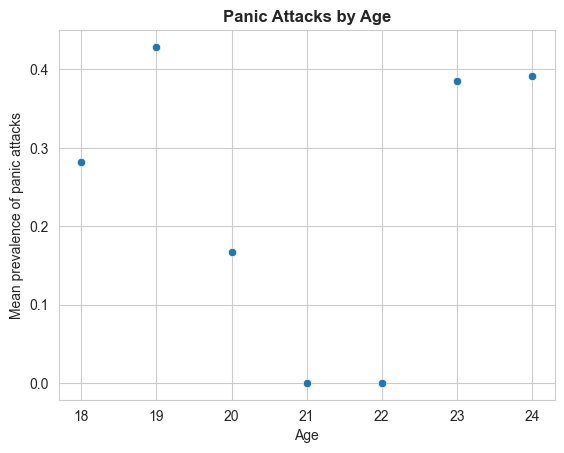

In [382]:
# Group df by age
# Select the panic attack column
# Take the mean of each age group
age_panic = df.groupby('Age')['Do you have Panic attack?'].mean().to_frame()

# Create the scatterplot
axs3 = sns.scatterplot(data=age_panic, x='Age', y='Do you have Panic attack?')
axs3.set_title('Panic Attacks by Age', fontweight='bold')
axs3.set_xlabel('Age')
axs3.set_ylabel('Mean prevalence of panic attacks')
plt.show()


**Observation**: Because panic attack occurrence is binary, a raw scatterplot produces only two y-values (0 and 1). Therefore, the data was grouped by age and the mean occurrence rate was plotted instead. Due to the small number of distinct ages, a bar or point plot would provide clearer insight than a scatter plot. Its is impossible to draw any definitive conclusion using this scatterplot.

# 🌟 Exercise 4: Visualizing Pairwise Relationships with Seaborn Pair Plot
### Objective:
Utilize Seaborn’s pairplot function to visualize the pairwise relationships and distributions across multiple variables in the dataset.

**Scenario**: You’re interested in understanding the relationships between students’ ages, CGPAs, and their mental health status regarding depression, anxiety, and panic attacks.

**Tasks**:

- Select a subset of columns relevant to the exercise: Age, CGPA, Depression, Anxiety, and Panic attacks. Assume these columns are appropriately coded as numerical values for simplicity.
- Use Seaborn’s pairplot to visualize pairwise relationships and distributions.
- Customize the plot with a hue based on one of the mental health conditions to differentiate the data points.

In [383]:
# Visualize column names
print(df.columns)

Index(['Choose your gender', 'Age', 'What is your course?',
       'Your current year of Study', 'What is your CGPA?', 'Marital status',
       'Do you have Depression?', 'Do you have Anxiety?',
       'Do you have Panic attack?',
       'Did you seek any specialist for a treatment?'],
      dtype='str')


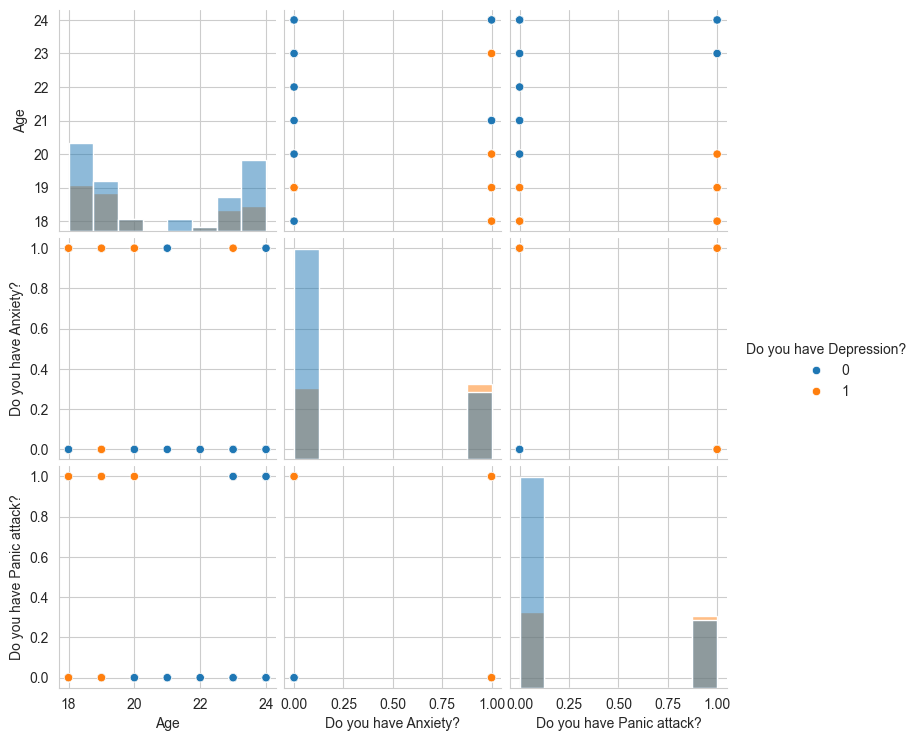

In [384]:
# Select relevant columns
reduced_df = df[['Age', 'What is your CGPA?', 'Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?']]

# Create pairplot
axs4 = sns.pairplot(reduced_df, hue='Do you have Depression?', diag_kind="hist"
)
plt.show()

**Observation**: Since most mental health variables are binary, pairplot produces limited interpretability because KDE and scatter relationships assume continuous data. The plot still demonstrates pairplot functionality, but boxplots and grouped summaries would be more appropriate for analysis.

# 🌟 Exercise 5: Creating a Heatmap to Visualize Correlations
### Objective:
Use Seaborn to create a heatmap that visualizes the correlation matrix of students’ age, CGPA, and mental health status indicators.

**Scenario**: You aim to identify any potential correlations between students’ age, CGPA, and their self-reported status on depression, anxiety, and panic attacks to find patterns that might need further investigation.

**Tasks**:

- Calculate the correlation matrix for the selected subset of your dataset.
- Use Seaborn’s heatmap function to visualize the correlation matrix.
- Customize the heatmap for better readability (e.g., annotating the correlation coefficients).

### Answer

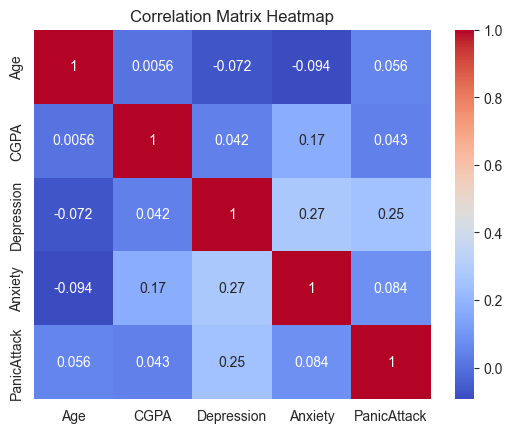

In [385]:
# Function to turn CGPA str into floats (otherwise the heatmap cannot be created)
# The numeric proxy for each CGPA will be the midpoint
def cgpa_midpoint(val):
    low, high = val.split(" - ")
    return (float(low) + float(high)) / 2

reduced_df["What is your CGPA?"] = reduced_df["What is your CGPA?"].apply(cgpa_midpoint)

reduced_df = reduced_df.rename(columns={
    "What is your CGPA?": "CGPA",
    "Do you have Depression?": "Depression",
    "Do you have Anxiety?": "Anxiety",
    "Do you have Panic attack?": "PanicAttack"
})

# Calculate the correlation matrix
correlation_matrix = reduced_df.corr()

# Create a heatmap
axs5 = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
axs5.set_title("Correlation Matrix Heatmap")
plt.show()

**Observation 1**: To include CGPA in the correlation analysis, each range was converted to a single representative numeric value using its midpoint. This preserves the ordering and approximate scale of the CGPA categories while allowing correlation coefficients to be computed.

**Observation 2**: From the heatmap, most correlations with Age and CGPA are weak (close to zero), suggesting little linear relationship in this sample. The mental health indicators show modest positive correlations with each other, which is reasonable since these conditions can co-occur. Because several variables are binary and CGPA is derived from ranges, the correlations should be interpreted as approximate indicators rather than precise measures of association.

# 🌟 Exercise 6: Analyzing Distributions and Relationships Using FacetGrid
### Objective:
Explore the distribution of CGPA across different levels of depression status using Seaborn’s FacetGrid.

**Scenario**: You are interested in exploring how students’ CGPA distributions vary among those who have reported depression versus those who haven’t.

**Tasks**:

- Use Seaborn’s FacetGrid to create a grid of histograms for CGPA, segmented by depression status.
- Map a histogram plot to each facet with appropriate customizations.
- Add titles and labels for clarity.

### Answer

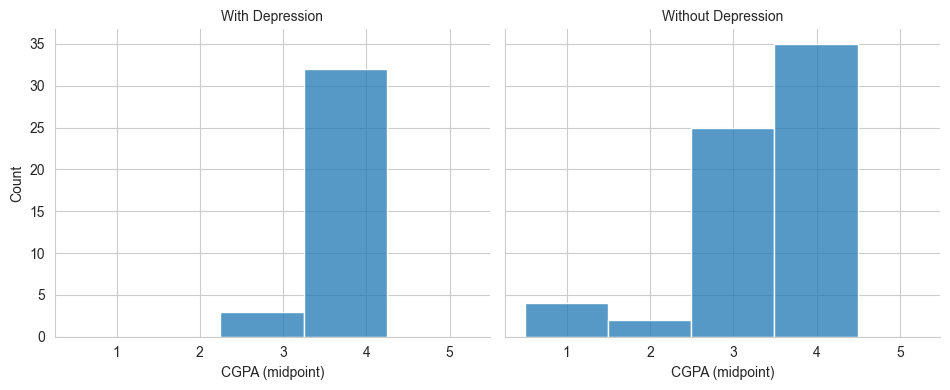

In [386]:
# Create label column in the df to use in the Facet Grid
reduced_df["Depression_label"] = reduced_df["Depression"].map({
    0: "Without Depression",
    1: "With Depression"
})

# Create a facet grid
g = sns.FacetGrid(
    reduced_df,
    col="Depression_label",   # split panels by depression status
    height=4,
    aspect=1.2
)

g.map(
    sns.histplot,
    "CGPA", # draw histogram of CGPA inside each subplot
    bins=8,
    kde=False
)

g.set_axis_labels("CGPA (midpoint)", "Count")
g.set_titles("{col_name}")

plt.show()

**Observation**: The Two count plots shows a higher number of students with higher CGPA's whithout depression than with depression -- a plausible result, since depression is a mental health condition that militates against productivity.